In [2]:
import numpy as np
import pandas as pd
import  matplotlib.pyplot as plt

import yfinance as yf


top_20_tickers = [
    "RELIANCE.NS", "HDFCBANK.NS", "BHARTIARTL.NS", "SBIN.NS", "ICICIBANK.NS",
    "TCS.NS", "BAJFINANCE.NS", "LT.NS", "INFY.NS", "HINDUNILVR.NS",
    "MARUTI.NS", "AXISBANK.NS", "M&M.NS", "TITAN.NS", "SUNPHARMA.NS",
    "HCLTECH.NS", "ITC.NS", "KOTAKBANK.NS", "NTPC.NS", "ONGC.NS"
]


data = yf.download(top_20_tickers, period="2y", interval="1d", auto_adjust=True)

data.head()

[*********************100%***********************]  20 of 20 completed


Price             Close                                                       \
Ticker      AXISBANK.NS BAJFINANCE.NS BHARTIARTL.NS   HCLTECH.NS HDFCBANK.NS   
Date                                                                           
2024-04-15  1056.231445    699.772461   1207.667725  1400.436768  727.449097   
2024-04-16  1050.191406    687.707764   1199.679321  1374.615479  734.530457   
2024-04-18  1022.336609    681.670654   1248.299683  1364.891846  727.449097   
2024-04-19  1027.428345    704.049438   1271.229126  1346.886963  745.261902   
2024-04-22  1052.237915    721.127747   1279.661255  1364.007812  735.966125   

Price                                                                        \
Ticker     HINDUNILVR.NS ICICIBANK.NS      INFY.NS      ITC.NS KOTAKBANK.NS   
Date                                                                          
2024-04-15   2108.957275  1060.959473  1382.241089  381.263397   358.822571   
2024-04-16   2134.670166  1049.841797  1331.683105  381.263397   357.715057   
2024-04-18   2128.902588  1038.428833  1336.202393  374.952271   356.547699   
2024-04-19   2145.051025  1050.038574  1328.670410  380.233948   357.725037   
2024-04-22   2154.567139  1069.125732  1348.912476  380.726288   361.177277   

Price       ...   Volume                                                     \
Ticker      ...    LT.NS   M&M.NS MARUTI.NS   NTPC.NS   ONGC.NS RELIANCE.NS   
Date        ...                                                               
2024-04-15  ...  1719910  2024919    831257  18126999  75063828    12902062   
2024-04-16  ...  2291042  1981730    579183  15328939  79082544     9366184   
2024-04-18  ...  3273257  3539862    679117  22966560  34136482    19005692   
2024-04-19  ...  2759031  3253248    635535  12867942  32658724    15741778   
2024-04-22  ...  2605754  2449171    342212  37382916  14184019    10350362   

Price                                                
Ticker       SBIN.NS SUNPHARMA.NS   TCS.NS TITAN.NS  
Date                                                 
2024-04-15  11356572      2474028  4200329   854076  
2024-04-16  13338991      2058697  3051420  1116890  
2024-04-18  14589648      3266796  3476284  1677946  
2024-04-19  10886554      2536516  2957749  1507940  
2024-04-22  17452186      1680307  1728883   668659  

[5 rows x 100 columns]

In [3]:

clean_data = data['Close']

clean_data = clean_data.ffill()

clean_data = clean_data.dropna()

print(clean_data.isnull().sum())

Ticker
AXISBANK.NS      0
BAJFINANCE.NS    0
BHARTIARTL.NS    0
HCLTECH.NS       0
HDFCBANK.NS      0
HINDUNILVR.NS    0
ICICIBANK.NS     0
INFY.NS          0
ITC.NS           0
KOTAKBANK.NS     0
LT.NS            0
M&M.NS           0
MARUTI.NS        0
NTPC.NS          0
ONGC.NS          0
RELIANCE.NS      0
SBIN.NS          0
SUNPHARMA.NS     0
TCS.NS           0
TITAN.NS         0
dtype: int64


Summary of 20 Companies:
               Annual Return  Annual Volatility
Ticker                                         
AXISBANK.NS         0.157615           0.246596
BAJFINANCE.NS       0.175718           0.282816
BHARTIARTL.NS       0.242376           0.215429
HCLTECH.NS          0.048254           0.244988
HDFCBANK.NS         0.074537           0.198781
HINDUNILVR.NS       0.031559           0.199909
ICICIBANK.NS        0.141538           0.196747
INFY.NS             0.001669           0.248667
ITC.NS             -0.100901           0.188617
KOTAKBANK.NS        0.061120           0.238979
LT.NS               0.109761           0.273748
M&M.NS              0.288581           0.302032
MARUTI.NS           0.070411           0.227822
NTPC.NS             0.101722           0.261840
ONGC.NS             0.112809           0.300040
RELIANCE.NS        -0.016805           0.215931
SBIN.NS             0.227775           0.252461
SUNPHARMA.NS        0.078554           0.197508
TCS.NS         

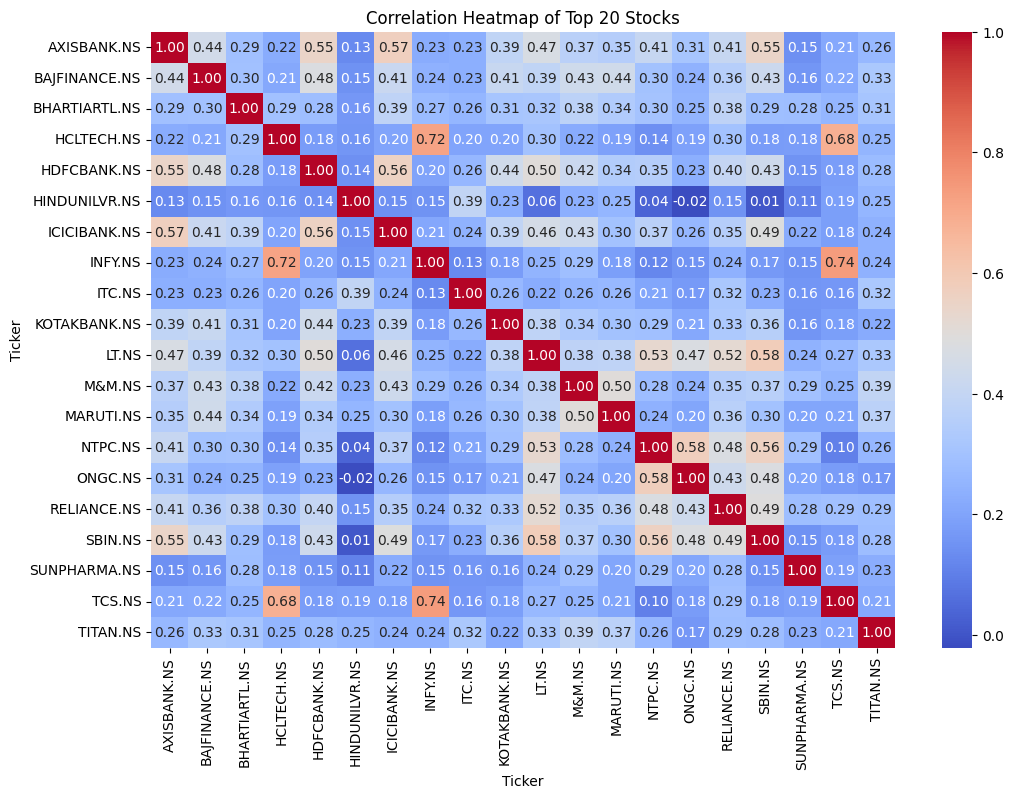

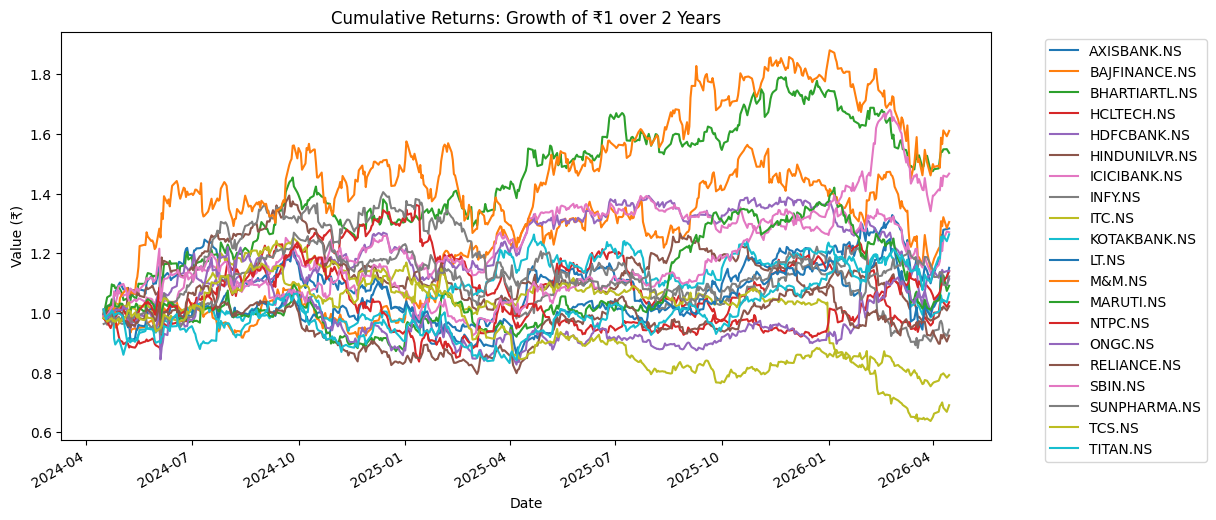

In [4]:
import seaborn as sns


returns = clean_data.pct_change().dropna()


annual_return = returns.mean() * 252


annual_volatility = returns.std() * np.sqrt(252)


summary = pd.DataFrame({
    'Annual Return': annual_return,
    'Annual Volatility': annual_volatility
})
print("Summary of 20 Companies:")
print(summary)


plt.figure(figsize=(12, 8))
sns.heatmap(returns.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap of Top 20 Stocks')
plt.show()


cumulative_returns = (1 + returns).cumprod()
cumulative_returns.plot(figsize=(12, 6))
plt.title('Cumulative Returns: Growth of ₹1 over 2 Years')
plt.ylabel('Value (₹)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

In [5]:
!pip install PyPortfolioOpt

   ---------------------------------------- 0.0/1.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.1 MB ? eta -:--:--
   --------- ------------------------------ 0.3/1.1 MB ? eta -:--:--
   --------- ------------------------------ 0.3/1.1 MB ? eta -:--:--
   --------- ------------------------------ 0.3/1.1 MB ? eta -:--:--
   --------- ------------------------------ 0.3/1.1 MB ? eta -:--:--
   --------- ------------------------------ 0.3/1.1 MB ? eta -:--:--
   --------- ------------------------------ 0.3/1.1 MB ? eta -:--:--
   --------- ------------------------------ 0.3/1.1 MB ? eta -:--:--
   ------------------ --------------------- 0.5/1.1 MB 164.5 kB/s eta 0:00:04
   ------------------ --------------------- 0.5/1.1 MB 164.5 kB/s eta 0:00:04
   ------------------ --------------------- 0.5/1.1 MB 164.5 kB/s eta 0:00:04
   ------------------ --------------------- 0.5/1.1 MB 164.5 kB/s eta 0:00:0


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
from pypfopt.efficient_frontier import EfficientFrontier
from pypfopt import risk_models
from pypfopt import expected_returns
import pandas as pd

# 1. Split the data: In-Sample (Training) vs Out-of-Sample (Testing)
# We use the first 75% of the data to "train" our plan
split_idx = int(len(returns) * 0.75)
train_returns = returns.iloc[:split_idx]
test_returns = returns.iloc[split_idx:] 


mu = expected_returns.mean_historical_return(train_returns, returns_data=True)
S = risk_models.sample_cov(train_returns, returns_data=True)


ef = EfficientFrontier(mu, S)


ef.add_constraint(lambda w: w <= 0.2)
ef.add_constraint(lambda w: w >= 0.02)

raw_weights = ef.max_sharpe(risk_free_rate=0.07)




cleaned_weights = ef.clean_weights()


print("--- Optimal Portfolio Weights ---")
weights_df = pd.Series(cleaned_weights).sort_values(ascending=False)
print(weights_df[weights_df > 0] * 100)


print("\n--- Expected Annual Performance (Based on Training Data) ---")
performance = ef.portfolio_performance(verbose=True, risk_free_rate=0.07)

--- Optimal Portfolio Weights ---
BHARTIARTL.NS    20.000
M&M.NS           20.000
HDFCBANK.NS      15.768
BAJFINANCE.NS    12.232
HCLTECH.NS        2.000
AXISBANK.NS       2.000
ICICIBANK.NS      2.000
HINDUNILVR.NS     2.000
INFY.NS           2.000
ITC.NS            2.000
KOTAKBANK.NS      2.000
LT.NS             2.000
MARUTI.NS         2.000
NTPC.NS           2.000
ONGC.NS           2.000
RELIANCE.NS       2.000
SBIN.NS           2.000
SUNPHARMA.NS      2.000
TCS.NS            2.000
TITAN.NS          2.000
dtype: float64

--- Expected Annual Performance (Based on Training Data) ---
Expected annual return: 25.3%
Annual volatility: 15.7%
Sharpe Ratio: 1.17


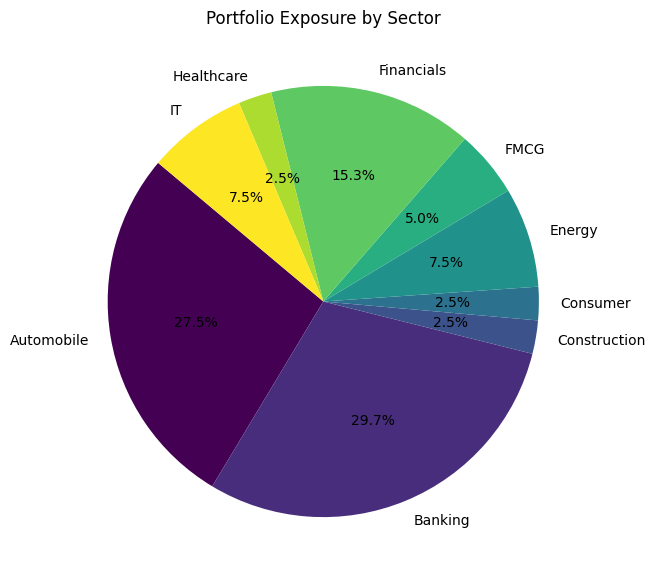

Sectoral Concentration:
Sector
Banking         0.23768
Automobile      0.22000
Financials      0.12232
IT              0.06000
Energy          0.06000
FMCG            0.04000
Construction    0.02000
Consumer        0.02000
Healthcare      0.02000
Name: Weight, dtype: float64


In [7]:
import matplotlib.pyplot as plt

# 1. Define the Sector Mapping for your Top 20
sector_map = {
    "HDFCBANK.NS": "Banking", "ICICIBANK.NS": "Banking", "AXISBANK.NS": "Banking",
    "SBIN.NS": "Banking", "KOTAKBANK.NS": "Banking", "BAJFINANCE.NS": "Financials",
    "RELIANCE.NS": "Energy", "NTPC.NS": "Energy", "ONGC.NS": "Energy",
    "TCS.NS": "IT", "INFY.NS": "IT", "HCLTECH.NS": "IT",
    "ITC.NS": "FMCG", "HINDUNILVR.NS": "FMCG",
    "M&M.NS": "Automobile", "MARUTI.NS": "Automobile",
    "LT.NS": "Construction", "TITAN.NS": "Consumer",
    "SUNPHARMA.NS": "Healthcare", "BEL.NS": "Capital Goods"
}

# 2. Create a DataFrame from your cleaned_weights (from Phase 3)
weights_data = pd.DataFrame.from_dict(cleaned_weights, orient='index', columns=['Weight'])
weights_data['Sector'] = weights_data.index.map(sector_map)

# 3. Group by Sector
sector_exposure = weights_data.groupby('Sector')['Weight'].sum()

# 4. Plot the Sectoral Pie Chart
plt.figure(figsize=(10, 7))
sector_exposure.plot(kind='pie', autopct='%1.1f%%', startangle=140, cmap='viridis')
plt.title('Portfolio Exposure by Sector')
plt.ylabel('') # Hide the 'Weight' label on the side
plt.show()

print("Sectoral Concentration:")
print(sector_exposure.sort_values(ascending=False))

[*********************100%***********************]  1 of 1 completed


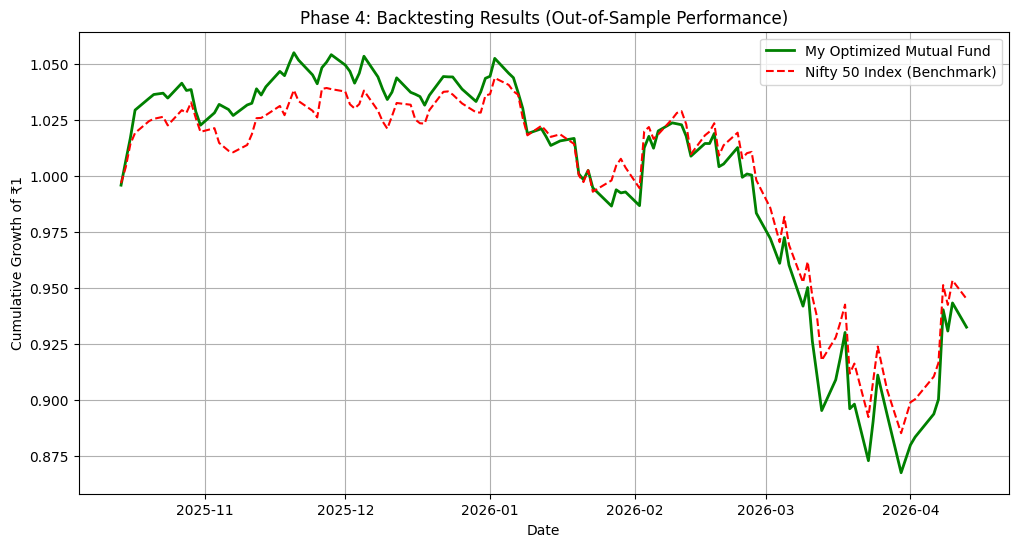

Total Portfolio Return (6 Months): -6.75%
Sharpe Ratio (Out-of-Sample): -1.18
Volatility (Annualized): 17.01%
Maximum Drawdown: -17.76%
Total Nifty 50 Return (6 Months): -5.49%


In [8]:
import yfinance as yf
import matplotlib.pyplot as plt

# Monthly Rebalancing
test_returns.index = pd.to_datetime(test_returns.index)

monthly_groups = test_returns.groupby(pd.Grouper(freq='ME'))

portfolio_returns = []

for _, group in monthly_groups:
    monthly_portfolio = group.dot(pd.Series(cleaned_weights))
    portfolio_returns.append(monthly_portfolio)

portfolio_test_returns = pd.concat(portfolio_returns).sort_index()


nifty_data = yf.download("^NSEI", start=test_returns.index[0], end=test_returns.index[-1])
nifty_returns = nifty_data['Close'].pct_change().dropna()


nifty_returns = nifty_returns.reindex(test_returns.index).dropna()
portfolio_test_returns = portfolio_test_returns.loc[nifty_returns.index]


portfolio_cum_growth = (1 + portfolio_test_returns).cumprod()
nifty_cum_growth = (1 + nifty_returns).cumprod()


plt.figure(figsize=(12, 6))
plt.plot(portfolio_cum_growth, label='My Optimized Mutual Fund', linewidth=2, color='green')
plt.plot(nifty_cum_growth, label='Nifty 50 Index (Benchmark)', linestyle='--', color='red')

plt.title('Phase 4: Backtesting Results (Out-of-Sample Performance)')
plt.xlabel('Date')
plt.ylabel('Cumulative Growth of ₹1')
plt.legend()
plt.grid(True)
plt.show()


total_return = (portfolio_cum_growth.iloc[-1] - 1) * 100
nifty_return = (nifty_cum_growth.iloc[-1].item() - 1) * 100

print(f"Total Portfolio Return (6 Months): {total_return:.2f}%")
rf = 0.07 / 252
sharpe = (portfolio_test_returns.mean() - rf) / portfolio_test_returns.std()
sharpe *= np.sqrt(252)

volatility = portfolio_test_returns.std() * np.sqrt(252)
cum = (1 + portfolio_test_returns).cumprod()
peak = cum.cummax()

drawdown = (cum - peak) / peak
max_dd = drawdown.min()

print(f"Sharpe Ratio (Out-of-Sample): {sharpe:.2f}")
print(f"Volatility (Annualized): {volatility:.2%}")
print(f"Maximum Drawdown: {max_dd:.2%}")
print(f"Total Nifty 50 Return (6 Months): {nifty_return:.2f}%")

In [9]:
# 1. Update your Sector Map to include 'Oil Dependency'
oil_producers = ["RELIANCE.NS", "ONGC.NS"]
oil_consumers = ["MARUTI.NS", "M&M.NS","NTPC.NS","SUNPHARMA.NS"] # Add others if in your 20

# 2. Define the Stress Scenario
producer_gain = 0.05  # +5% 
consumer_loss = -0.10 # -10%

# 3. Calculate Weights
prod_weight = sum(cleaned_weights.get(t, 0) for t in oil_producers)
cons_weight = sum(cleaned_weights.get(t, 0) for t in oil_consumers)

# 4. Calculate Net Impact
net_impact = (prod_weight * producer_gain) + (cons_weight * consumer_loss)

print(f"--- STRESS TEST: Oil Price Spike Scenario ---")
print(f"Exposure to Oil Producers: {prod_weight*100:.2f}%")
print(f"Exposure to Oil Consumers: {cons_weight*100:.2f}%")
print(f"Net Portfolio Impact: {net_impact*100:.2f}%")

--- STRESS TEST: Oil Price Spike Scenario ---
Exposure to Oil Producers: 4.00%
Exposure to Oil Consumers: 26.00%
Net Portfolio Impact: -2.40%
